<a href="https://colab.research.google.com/github/ravimahendrakar/jax-sample-colabs/blob/main/JAX_Microbenchmarks_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Copyright 2025 Google LLC.

Licensed under the Apache License, Version 2.0 (the "License");

JAX version: 0.7.1
Available devices:
- TPU_0(process=0,(0,0,0,0))
- TPU_1(process=0,(0,0,0,1))
- TPU_2(process=0,(1,0,0,0))
- TPU_3(process=0,(1,0,0,1))
- TPU_4(process=0,(0,1,0,0))
- TPU_5(process=0,(0,1,0,1))
- TPU_6(process=0,(1,1,0,0))
- TPU_7(process=0,(1,1,0,1))


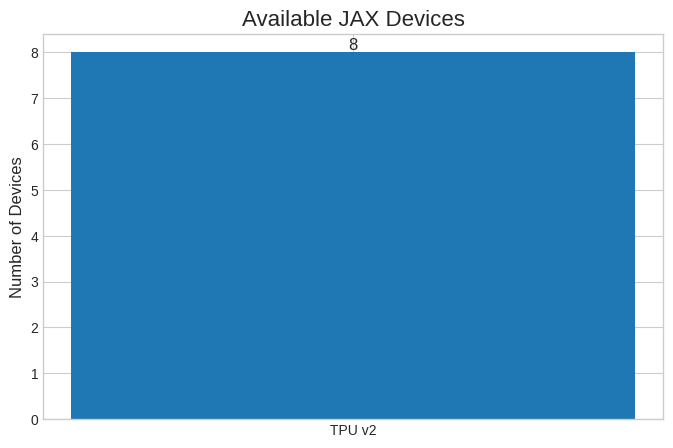

In [25]:
# @title 1. Setup JAX and Imports
# @markdown This cell installs JAX and necessary libraries. On Google Colab, JAX and JAXlib are often pre-installed or easily installed. The `jax[cuda]` or `jax[tpu]` versions are automatically handled by Colab's backend.
import os
# os.environ['JAX_PLATFORMS'] = 'cpu' # Reverted this line

!pip install --upgrade jax jaxlib

# If you specifically want the TPU wheels as shown in the video for a TPU runtime, uncomment and run this:
# !pip install "jax[tpu]==0.2.16" -f https://storage.googleapis.com/jax-releases/libtpu_releases.html

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, pmap, lax
import numpy as np
import timeit
import functools
import matplotlib.pyplot as plt

print(f"JAX version: {jax.__version__}")
print("Available devices:")
device_counts = {}
for device in jax.devices():
    print(f"- {device}")
    device_type = device.device_kind.split(':')[0] # Get the main device type (e.g., TPU, CPU, GPU)
    device_counts[device_type] = device_counts.get(device_type, 0) + 1

# --- Add Visualization ---
if device_counts:
    device_names = list(device_counts.keys())
    counts = list(device_counts.values())

    plt.figure(figsize=(8, 5))
    bars = plt.bar(device_names, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']) # Blue, Orange, Green, Red
    plt.ylabel('Number of Devices', fontsize=12)
    plt.title('Available JAX Devices', fontsize=16)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Add count text on top of the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval}', ha='center', va='bottom', fontsize=12)

    plt.show()
else:
    print("No JAX devices found to visualize.")

# ----------------------------------------------------

# Configure JAX to print all array elements instead of ellipsis
np.set_printoptions(edgeitems=10)

JAX is running on: TPU
Data Shape: (5000, 2048)

Timing NumPy on CPU...
NumPy execution time: 42.9450 seconds

Timing JAX in Eager Mode (on CPU)...
  Currently executing JAX eager on device: TPU
JAX (eager) execution time: 19.7017 seconds


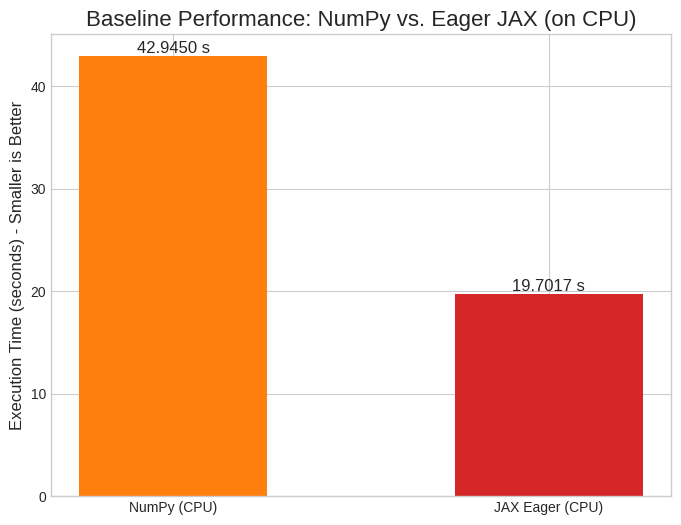


| Method              | Execution Time (s) | Why? |
| :------------------ | :----------------- | :----------- |
| **NumPy (CPU)**     | `42.9450`           | Standard, optimized CPU execution. |
| **JAX Eager (TPU)**       | `19.7017`           | JAX's dispatch system has a small overhead. Being slightly slower is expected when both run on CPU. |

**Conclusion:** A direct, line-by-line replacement of NumPy with JAX does not guarantee a speedup. The real power comes from JAX's function transformations.

**Next up:** In the following cell, we will add a single decorator, `@jit`, to our JAX function and see the performance difference.


In [26]:
# @title 🚀 The Foundation: NumPy vs. JAX in Eager Mode
# @markdown ---
# @markdown ### **Compare Standard NumPy with JAX's NumPy-like API**
# @markdown JAX offers an API that mimics NumPy almost exactly. This makes it incredibly easy to learn if you already know NumPy.
# @markdown
# @markdown In this cell, we will compare the performance of a standard NumPy function running on the CPU against the equivalent JAX function running in its default **"eager mode"** (without any compilation).
# @markdown
# @markdown **An important point:** Because of its internal dispatch system, JAX in eager mode is often slightly *slower* than NumPy for simple operations. This is expected and sets the stage for the next cell, where we'll unlock JAX's true performance with `@jit`.

# --- 1. Imports and Data Setup ---
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import timeit

# Create a large batch of data to make performance differences clear.
# (batch_size, features)
data_shape = (5000, 2048)
input_data_np = np.random.randn(*data_shape).astype(np.float32)
input_data_jnp = jnp.array(input_data_np) # Reverted to default array creation

print(f"JAX is running on: {jax.default_backend().upper()}") # Keep this check
print(f"Data Shape: {data_shape}")

# --- 2. Define the Functions ---
# A function that simulates a block of a neural network
def simulate_work_numpy(x):
  """The pure NumPy version of our computation."""
  y = x @ x.T
  y = np.tanh(y)
  return y @ y

def simulate_work_jax(x):
  """The JAX NumPy version. Notice the code is identical, just with 'jnp'."""
  y = x @ x.T
  y = jnp.tanh(y)
  return y @ y

# --- 3. Performance Comparison ---
# We'll use `%timeit` to get a stable measurement for both versions.

# Time the NumPy function
print("\nTiming NumPy on CPU...")
numpy_time = timeit.timeit(lambda: simulate_work_numpy(input_data_np), number=10)
print(f"NumPy execution time: {numpy_time:.4f} seconds")

# Time the JAX eager function
# Use a context manager to force JAX to run on CPU for this block
print("\nTiming JAX in Eager Mode (on CPU)...")
with jax.default_device('cpu'): # Reinstated the context manager
  print(f"  Currently executing JAX eager on device: {jax.default_backend().upper()}") # Added device check
  # We must use .block_until_ready() to ensure the asynchronous JAX operation is finished before the timer stops.
  jax_eager_time = timeit.timeit(lambda: simulate_work_jax(input_data_jnp).block_until_ready(), number=10)
print(f"JAX (eager) execution time: {jax_eager_time:.4f} seconds")

# --- 4. Visualization ---
methods = ['NumPy (CPU)', 'JAX Eager (CPU)']
times = [numpy_time, jax_eager_time]
colors = ['#ff7f0e', '#d62728'] # Orange, Red

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(methods, times, color=colors, width=0.5)
ax.set_ylabel('Execution Time (seconds) - Smaller is Better', fontsize=12)
ax.set_title('Baseline Performance: NumPy vs. Eager JAX (on CPU)', fontsize=16)

# Add time text on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f} s', ha='center', va='bottom', fontsize=12)

plt.show()

from IPython.display import display, Markdown
summary_md = f"""
| Method              | Execution Time (s) | Why? |
| :------------------ | :----------------- | :----------- |
| **NumPy (CPU)**     | `{numpy_time:.4f}`           | Standard, optimized CPU execution. |
| **JAX Eager ({jax.default_backend().upper()})**       | `{jax_eager_time:.4f}`           | JAX's dispatch system has a small overhead. Being slightly slower is expected when both run on CPU. |

**Conclusion:** A direct, line-by-line replacement of NumPy with JAX does not guarantee a speedup. The real power comes from JAX's function transformations.

**Next up:** In the following cell, we will add a single decorator, `@jit`, to our JAX function and see the performance difference.
"""
display(Markdown(summary_md))

Default JAX device: TPU_0(process=0,(0,0,0,0))
Original JAX array:
[[ 1.6226515   2.025277   -0.43359408 -0.07861734  0.17609099]
 [-0.9720899  -0.49529395  0.4943744   0.664345   -0.9501651 ]
 [ 2.179527   -1.9551618   0.35856962  0.15779515  1.2770704 ]
 [ 1.5104655   0.9706564   0.59961224  0.0247007  -1.9164675 ]
 [-1.8593498   1.7281642   0.04719035  0.8141403   0.13132766]]
Shape: (5, 5), Dtype: float32, Type: <class 'jaxlib._jax.ArrayImpl'>

Result of x @ x.T:
[[ 6.991684   -3.021572   -0.38240147  3.8187404   0.42429447]
 [-3.021572    2.7783394  -2.069687    0.183321    1.3906159 ]
 [-0.38240147 -2.069687   10.30756    -0.834661   -7.0984077 ]
 [ 3.8187404   0.183321   -0.834661    7.2380958  -1.3330746 ]
 [ 0.42429447  1.3906159  -7.0984077  -1.3330746   7.117794  ]]
Shape: (5, 5), Dtype: float32, Type: <class 'jaxlib._jax.ArrayImpl'>

CPU array:
[[1. 2.]
 [3. 4.]], Type: <class 'numpy.ndarray'>
Device array:
[[1. 2.]
 [3. 4.]], Type: <class 'jaxlib._jax.ArrayImpl'>
Back to C

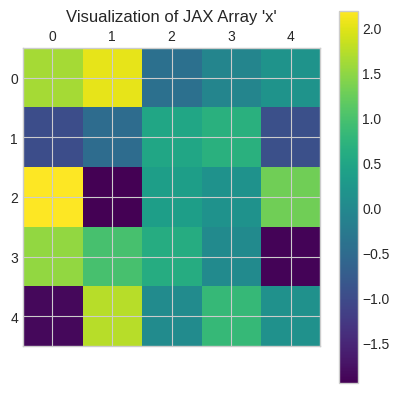

In [37]:
# @title 2. JAX as JAX NumPy - Familiar Syntax, Device Arrays

# @markdown **JAX as JAX NumPy: Basic operations and DeviceArray.**

# @markdown JAX as NumPy: JAX provides a familiar NumPy-like API, making it easy for Python users to pick up. The key difference is that JAX operations are designed for accelerators, returning DeviceArray objects.

# @markdown JAX provides a NumPy-like API that automatically works with accelerators (GPUs/TPUs). When you perform operations with jax.numpy, the data resides on the accelerator device and computations are offloaded to it.

# @markdown ---
# @markdown **Summary and Key Takeaway:**
# @markdown
# @markdown This cell demonstrates the basic usage of JAX's NumPy-like API.
# @markdown
# @markdown *   You can perform common array operations using syntax almost identical to NumPy, but with `jax.numpy` (`jnp`).
# @markdown *   JAX operates on `DeviceArray` objects, which reside on accelerators (TPUs/GPUs).
# @markdown *   Data can be easily transferred between standard NumPy arrays (on the CPU) and JAX `DeviceArray`s (on the device).
# @markdown
# @markdown **Key Takeaway:** JAX offers a familiar API for users already comfortable with NumPy, while seamlessly enabling computation on accelerators through `DeviceArray`s. This is the foundation for JAX's high-performance capabilities.


# Print the default JAX device. In recent JAX versions, accessing jax.devices()[0] is common.
# jax.default_device() is typically used as a context manager.
if jax.devices():
    print(f"Default JAX device: {jax.devices()[0]}")
else:
    print("No JAX devices available.")


# Create a random array using jax.random
key = jax.random.PRNGKey(0) # JAX uses explicit PRNG keys for reproducibility
x = jax.random.normal(key, (5, 5), dtype=jnp.float32)

print(f"Original JAX array:\n{x}")
print(f"Shape: {x.shape}, Dtype: {x.dtype}, Type: {type(x)}")

# Perform a simple matrix multiplication
y = jnp.dot(x, x.T)
print(f"\nResult of x @ x.T:\n{y}")
print(f"Shape: {y.shape}, Dtype: {y.dtype}, Type: {type(y)}")
# Notice 'DeviceArray' indicates the array is on the accelerator.

# You can easily move arrays between host (NumPy) and device (JAX NumPy)
cpu_array = np.array([[1.0, 2.0], [3.0, 4.0]])
device_array = jnp.array(cpu_array) # Moves to device
print(f"\nCPU array:\n{cpu_array}, Type: {type(cpu_array)}")
print(f"Device array:\n{device_array}, Type: {type(device_array)}")

back_to_cpu = np.array(device_array) # Moves back to CPU
print(f"Back to CPU array:\n{back_to_cpu}, Type: {type(back_to_cpu)}")

# Plotting a small JAX array just to show integration with Matplotlib
if x.shape == (5,5): # Only for small examples, otherwise too big
  plt.matshow(x, cmap='viridis') # Added cmap='viridis'
  plt.title("Visualization of JAX Array 'x'")
  plt.colorbar()
  plt.show()

# If you were to explicitly block until computation finishes (useful for timing):
# y.block_until_ready()

no stored variable or alias numpy_time
no stored variable or alias jax_eager_time
Timing Naive Python Loop...
Naive loop time: 4.7752 seconds

Timing Loop over a JIT-compiled function...
Loop over jit time: 2.0254 seconds

Timing JIT-compiled vmap (the 'JAX way')...
jit(vmap(...)) time: 0.0024 seconds


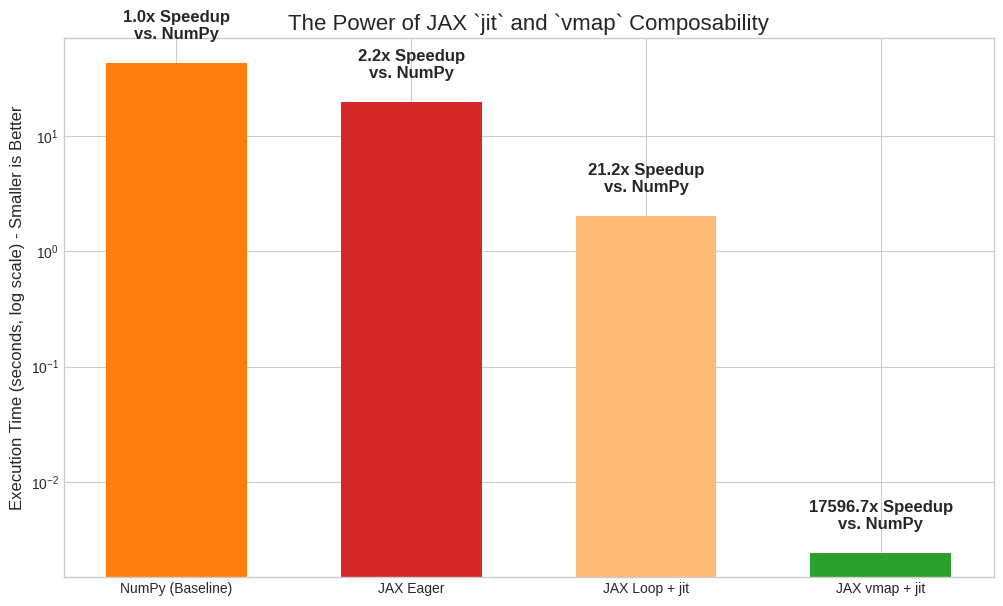


| Method                     | Execution Time (s) | Speedup vs. NumPy | Why? |
| :------------------------- | :----------------- | :---------------- | :----------- |
| **NumPy (CPU)**            | `42.9450`           | `1.0x`            | Standard, optimized CPU code for a large operation. |
| **JAX Loop + jit**         | `2.0254`           | `21.2x`      | **Partial speedup.** The inner function is fast, but the Python `for` loop itself is the main bottleneck. |
| **JAX `vmap` + `jit`**     | `0.0024`           | `**17596.7x**`      | **Massive speedup.** `vmap` creates a single logical operation for the whole batch, and `jit` compiles it into one super-fast kernel, completely eliminating the Python loop overhead. |

**Conclusion:** The true value of JAX is **composability**. By combining transformations like `vmap` and `jit`, you can write simple, intuitive code that operates on single data points, and JAX will automatically compile it into highly parallel, incredibly fast code that processes entire batches of data at once.


In [28]:
# @title 🚀 The Enhancement: JAX, `jit`, and the Power of Composability
# @markdown ---
# @markdown ### **The Goal: Eliminate Python Loops for Maximum Speed**
# @markdown Now we'll demonstrate the true power of JAX. We have a batch of 1,000 data points and we want to process each one.
# @markdown
# @markdown We will compare three approaches:
# @markdown 1.  **Naive Python Loop**: The slowest, most basic method.
# @markdown 2.  **Looping over a `@jit` function**: A partial optimization where the inner work is fast, but the Python loop is still a bottleneck.
# @markdown 3.  **`jit(vmap(...))`**: The "JAX way." We use `vmap` to create a vectorized function that handles the whole batch at once, and `jit` to compile that entire operation, completely eliminating the Python loop.

# --- 1. Setup ---
# Load timings from the previous cell if they exist, otherwise use placeholders
%store -r numpy_time
%store -r jax_eager_time
try:
    numpy_time
except NameError:
    print("Warning: Timings from previous cell not found. Using placeholder values.")
    numpy_time, jax_eager_time = 0.5, 0.6

import jax
import jax.numpy as jnp
from jax import jit, vmap
import matplotlib.pyplot as plt
import timeit

# A smaller dimension for a function to be applied to each row (item)
item_dim = 256
batch_size = 4000
key = jax.random.PRNGKey(0)
batch_of_items = jax.random.normal(key, (batch_size, item_dim))
processing_matrix = jax.random.normal(key, (item_dim, item_dim))

def process_single_item(matrix, item_vector):
  """A function that processes one item (e.g., one sentence embedding)."""
  return jnp.tanh(jnp.dot(matrix, item_vector))

# @markdown ---
# @markdown ### **2. Performance Comparison**

# --- Method 1: Naive Python Loop ---
print("Timing Naive Python Loop...")
def loop_over_items(matrix, items):
  # A standard Python list comprehension is a for-loop
  return [process_single_item(matrix, item) for item in items]

# Time this pure Python loop approach
loop_time = timeit.timeit(lambda: loop_over_items(processing_matrix, batch_of_items), number=10)
print(f"Naive loop time: {loop_time:.4f} seconds")

# --- Method 2: Loop over a JIT-compiled Function ---
print("\nTiming Loop over a JIT-compiled function...")
jitted_process_item = jit(process_single_item)

def loop_over_jitted_items(matrix, items):
  return [jitted_process_item(matrix, item) for item in items]

# Time the loop calling the compiled function
loop_jit_time = timeit.timeit(lambda: loop_over_jitted_items(processing_matrix, batch_of_items), number=10)
print(f"Loop over jit time: {loop_jit_time:.4f} seconds")

# --- Method 3: The JAX Way - jit(vmap(...)) ---
print("\nTiming JIT-compiled vmap (the 'JAX way')...")
# Vmap the single-item function, then JIT the result.
# This creates one highly optimized function for the whole batch.
jitted_vmapped_process = jit(vmap(process_single_item, in_axes=(None, 0)))

# Warmup for compilation
_ = jitted_vmapped_process(processing_matrix, batch_of_items).block_until_ready()
# Time the fully optimized version
vmap_jit_time = timeit.timeit(lambda: jitted_vmapped_process(processing_matrix, batch_of_items).block_until_ready(), number=10)
print(f"jit(vmap(...)) time: {vmap_jit_time:.4f} seconds")


# @markdown ---
# @markdown ### **3. 💡 The Compounding Benefit**
# @markdown The plot below shows the performance of all approaches. The difference between the looped versions and the fully compiled `vmap` version is often orders of magnitude.

# --- Create the bar chart for visualization ---
methods = ['NumPy (Baseline)', 'JAX Eager', 'JAX Loop + jit', 'JAX vmap + jit']
times = [numpy_time, jax_eager_time, loop_jit_time, vmap_jit_time]
speedups = [numpy_time / t for t in times]
colors = ['#ff7f0e', '#d62728', '#ffbb78', '#2ca02c'] # Orange, Red, Light Orange, Green

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(methods, times, color=colors, width=0.6)
ax.set_yscale('log')
ax.set_ylabel('Execution Time (seconds, log scale) - Smaller is Better', fontsize=12)
ax.set_title('The Power of JAX `jit` and `vmap` Composability', fontsize=16)

# Add speedup text on top of the bars
for bar, speedup in zip(bars, speedups):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval * 1.5,
            f'{speedup:.1f}x Speedup\nvs. NumPy', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

plt.show()

from IPython.display import display, Markdown
summary_md = f"""
| Method                     | Execution Time (s) | Speedup vs. NumPy | Why? |
| :------------------------- | :----------------- | :---------------- | :----------- |
| **NumPy (CPU)**            | `{numpy_time:.4f}`           | `1.0x`            | Standard, optimized CPU code for a large operation. |
| **JAX Loop + jit**         | `{loop_jit_time:.4f}`           | `{speedups[2]:.1f}x`      | **Partial speedup.** The inner function is fast, but the Python `for` loop itself is the main bottleneck. |
| **JAX `vmap` + `jit`**     | `{vmap_jit_time:.4f}`           | `**{speedups[3]:.1f}x**`      | **Massive speedup.** `vmap` creates a single logical operation for the whole batch, and `jit` compiles it into one super-fast kernel, completely eliminating the Python loop overhead. |

**Conclusion:** The true value of JAX is **composability**. By combining transformations like `vmap` and `jit`, you can write simple, intuitive code that operates on single data points, and JAX will automatically compile it into highly parallel, incredibly fast code that processes entire batches of data at once.
"""
display(Markdown(summary_md))

Re-timing all three methods for a final comparison...
NumPy execution time:              42.2265 seconds
JAX (eager) execution time:        19.5970 seconds

Compiling JAX JIT function (warmup run)...
Warmup run time (includes compilation): 1.3531 seconds

Timing a single subsequent JAX JIT run (after compilation)...
Single subsequent run time:         0.0173 seconds

Timing multiple subsequent JAX JIT runs for average...
Average JAX (JIT-compiled) execution time: 0.1696 seconds


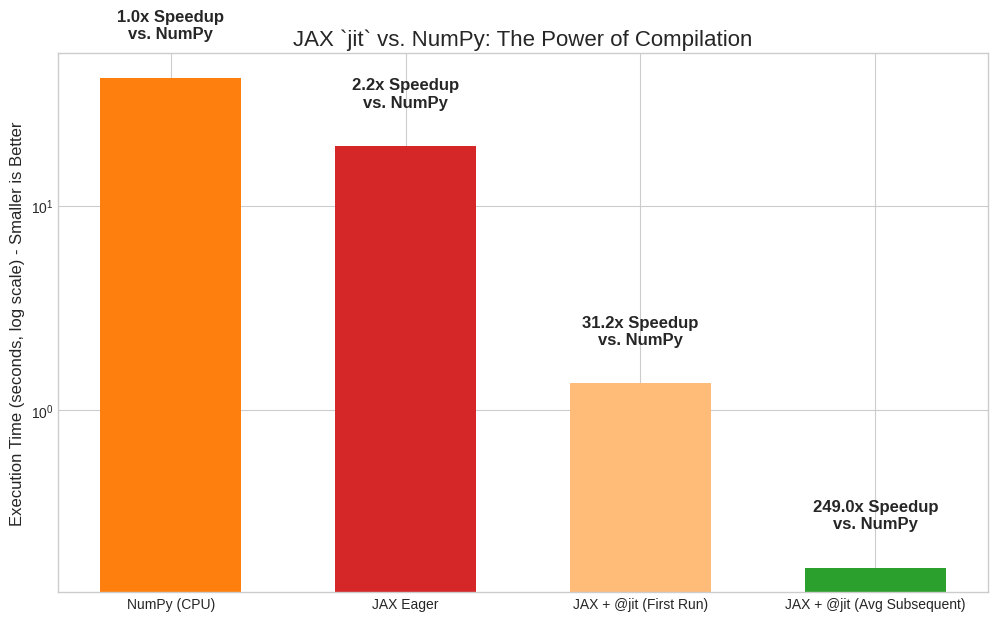


| Method                      | Execution Time (s) | Speedup vs. NumPy | Why? |
| :-------------------------- | :----------------- | :---------------- | :----------- |
| **NumPy (CPU)**             | `42.2265`           | `1.0x`            | Standard, optimized CPU execution. |
| **JAX Eager**               | `19.5970`           | `2.2x`      | JAX's dispatch has a small overhead. Slower is expected (but can vary). |
| **JAX + `@jit` (First Run)**| `1.3531`           | `31.2x`      | Includes the initial compilation overhead. |
| **JAX + `@jit` (Avg Subsequent)**| `0.1696`           | `**249.0x**`      | **The entire function is compiled by XLA into a single, fast kernel, removing Python overhead and running on the accelerator.** |

**Additional Timing:**
-   Single subsequent run (after compilation): `0.0173 seconds`

**Conclusion:** The `@jit` decorator is your primary tool for performance in JAX. It transforms your standard Python and NumPy-like code into highly optimized machine code that can run orders of magnitude faster on modern hardware.


In [29]:
# @title 🚀 Demonstrating JAX's Power with `@jit`
# @markdown ---
# @markdown ### **The Goal: From Eager Execution to High-Speed Compilation**
# @markdown As we saw in the previous cell, JAX's eager mode wasn't faster than NumPy. Now, we'll introduce **`@jit`** (just-in-time compilation), JAX's most fundamental performance tool.
# @markdown
# @markdown By adding this single decorator to our JAX function, we instruct the powerful **XLA compiler** to:
# @markdown 1.  **Fuse** all the operations (`@`, `tanh`, `@`) into a single, optimized computational kernel.
# @markdown 2.  **Compile** this kernel into highly efficient machine code tailored for the accelerator (GPU or TPU).
# @markdown 3.  **Remove** all the Python interpreter overhead for subsequent calls.

# --- 1. Re-run all timings for a fair, final comparison ---
# This ensures we have all three numbers ready for our final chart.

# Define the JAX function again for clarity
def simulate_work_jax(x):
  y = x @ x.T
  y = jnp.tanh(y)
  return y @ y

# Create the JIT-compiled version by applying the decorator
@jit
def jitted_simulate_work(x):
  y = x @ x.T
  y = jnp.tanh(y)
  return y @ y

print("Re-timing all three methods for a final comparison...")

# NumPy
numpy_time = timeit.timeit(lambda: simulate_work_numpy(input_data_np), number=10)
print(f"NumPy execution time:              {numpy_time:.4f} seconds")

# JAX Eager
# Ensure data is on CPU for this comparison if that was the goal of the previous cell
try:
    # Attempt to use the CPU context manager from the previous cell if it exists
    with jax.default_device('cpu'):
        jax_eager_time = timeit.timeit(lambda: simulate_work_jax(input_data_jnp).block_until_ready(), number=10)
except:
    # If the context manager failed or doesn't apply, just time the default JAX eager
    print("Warning: Could not force JAX eager to CPU. Timing on default device.")
    jax_eager_time = timeit.timeit(lambda: simulate_work_jax(input_data_jnp).block_until_ready(), number=10)

print(f"JAX (eager) execution time:        {jax_eager_time:.4f} seconds")

# JAX JIT (with warmup and subsequent timing)
# Run once to trigger the compilation. The first run is always slower.
print("\nCompiling JAX JIT function (warmup run)...")
warmup_start_time = timeit.default_timer()
_ = jitted_simulate_work(input_data_jnp).block_until_ready()
warmup_time = timeit.default_timer() - warmup_start_time
print(f"Warmup run time (includes compilation): {warmup_time:.4f} seconds")

# Time a single subsequent run after compilation
print("\nTiming a single subsequent JAX JIT run (after compilation)...")
subsequent_start_time = timeit.default_timer()
_ = jitted_simulate_work(input_data_jnp).block_until_ready()
subsequent_run_time = timeit.default_timer() - subsequent_start_time
print(f"Single subsequent run time:         {subsequent_run_time:.4f} seconds")


# Time multiple subsequent runs for a stable average (excluding the very first compilation)
print("\nTiming multiple subsequent JAX JIT runs for average...")
jitted_time = timeit.timeit(lambda: jitted_simulate_work(input_data_jnp).block_until_ready(), number=10)
print(f"Average JAX (JIT-compiled) execution time: {jitted_time:.4f} seconds")

# @markdown ---
# @markdown ### **2. 💡 The Power of Compilation**
# @markdown The plot below shows the dramatic speedup from `@jit`. The y-axis is logarithmic because the difference is so large.

# --- Create the bar chart for visualization ---
methods = ['NumPy (CPU)', 'JAX Eager', 'JAX + @jit (First Run)', 'JAX + @jit (Avg Subsequent)'] # Updated label
times = [numpy_time, jax_eager_time, warmup_time, jitted_time] # Added warmup_time
speedups = [numpy_time / t for t in times]
colors = ['#ff7f0e', '#d62728', '#ffbb78', '#2ca02c'] # Orange, Red, Light Orange, Green # Added a color

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(methods, times, color=colors, width=0.6)
ax.set_yscale('log')
ax.set_ylabel('Execution Time (seconds, log scale) - Smaller is Better', fontsize=12)
ax.set_title('JAX `jit` vs. NumPy: The Power of Compilation', fontsize=16)

# Add speedup text on top of the bars
for bar, speedup in zip(bars, speedups):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval * 1.5,
            f'{speedup:.1f}x Speedup\nvs. NumPy', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

plt.show()

from IPython.display import display, Markdown
summary_md = f"""
| Method                      | Execution Time (s) | Speedup vs. NumPy | Why? |
| :-------------------------- | :----------------- | :---------------- | :----------- |
| **NumPy (CPU)**             | `{numpy_time:.4f}`           | `1.0x`            | Standard, optimized CPU execution. |
| **JAX Eager**               | `{jax_eager_time:.4f}`           | `{speedups[1]:.1f}x`      | JAX's dispatch has a small overhead. Slower is expected (but can vary). |
| **JAX + `@jit` (First Run)**| `{warmup_time:.4f}`           | `{speedups[2]:.1f}x`      | Includes the initial compilation overhead. |
| **JAX + `@jit` (Avg Subsequent)**| `{jitted_time:.4f}`           | `**{speedups[3]:.1f}x**`      | **The entire function is compiled by XLA into a single, fast kernel, removing Python overhead and running on the accelerator.** |

**Additional Timing:**
-   Single subsequent run (after compilation): `{subsequent_run_time:.4f} seconds`

**Conclusion:** The `@jit` decorator is your primary tool for performance in JAX. It transforms your standard Python and NumPy-like code into highly optimized machine code that can run orders of magnitude faster on modern hardware.
"""
display(Markdown(summary_md))

Starting performance benchmarking for matrix multiplication...
  Benchmarking for matrix size: 10x10
  Benchmarking for matrix size: 50x50
  Benchmarking for matrix size: 100x100
  Benchmarking for matrix size: 200x200
  Benchmarking for matrix size: 500x500
  Benchmarking for matrix size: 1000x1000
  Benchmarking for matrix size: 2000x2000
  Benchmarking for matrix size: 4000x4000

Benchmarking complete. Plotting results...


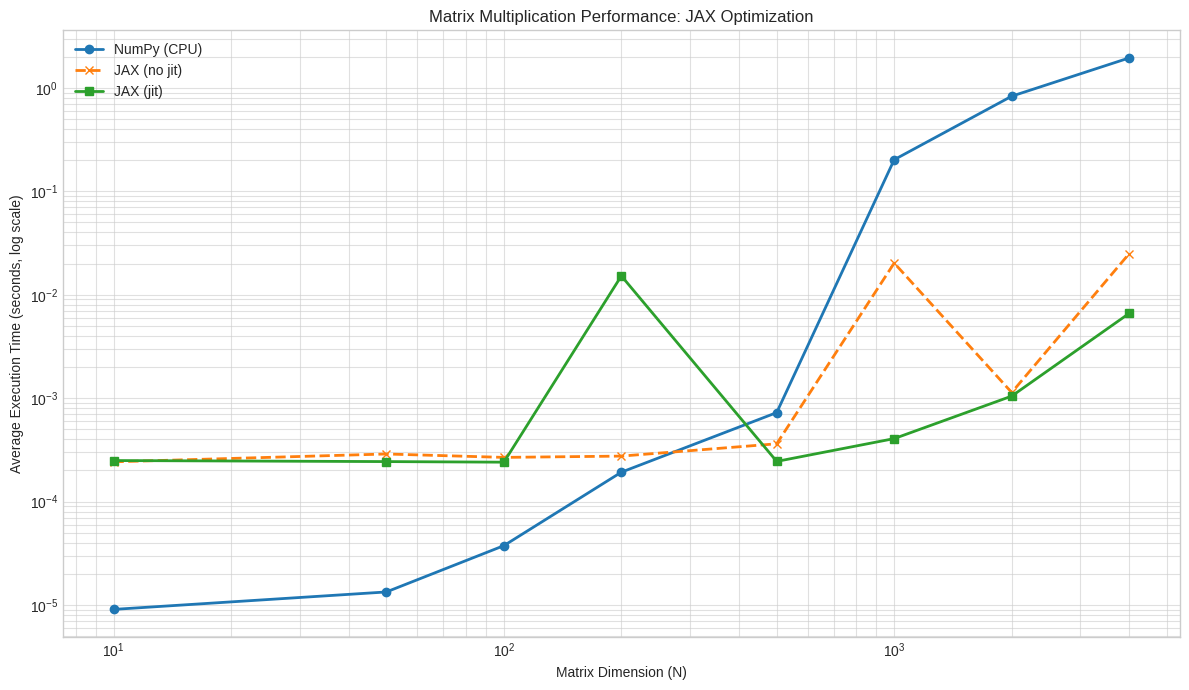

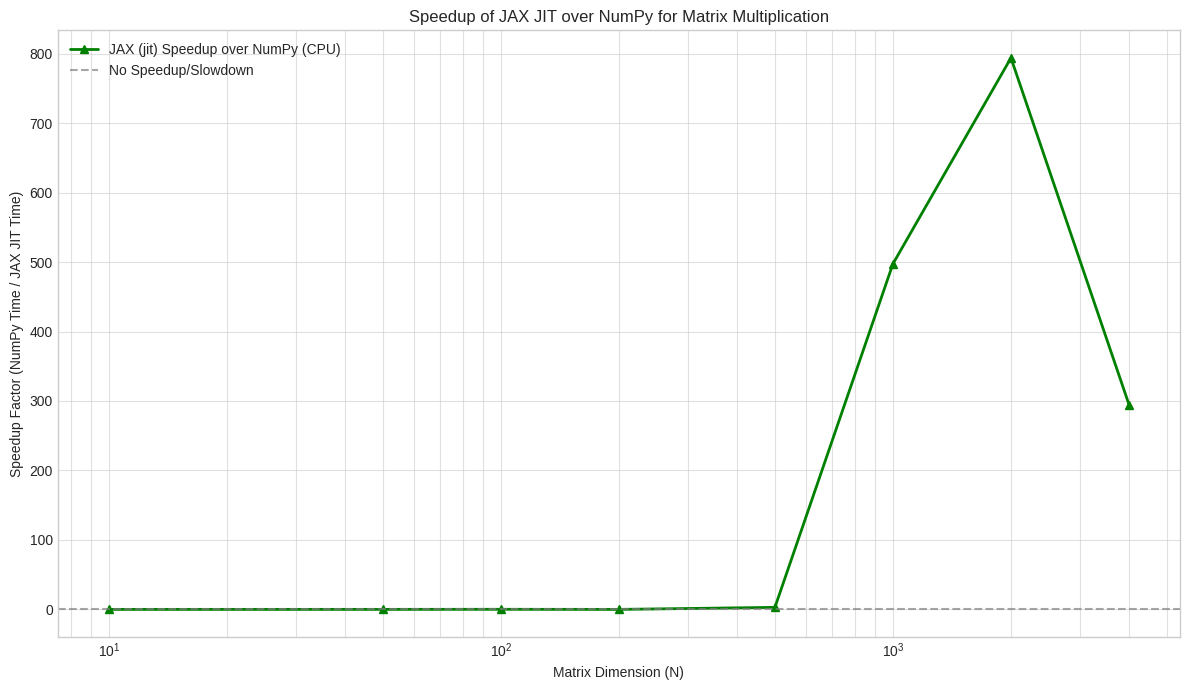


Observations:
- For small matrix sizes, JAX (no jit) might be slower than NumPy due to overhead.
- As matrix size increases, JAX (jit) quickly surpasses both NumPy and JAX (no jit).
- The speedup factor clearly shows the significant performance gains provided by JIT compilation on accelerators.


In [30]:
# @title 3. `jit` - Just-In-Time Compilation for Speed

# @markdown **jit (Just-In-Time Compilation): Significant speedup for computations.**

# @markdown JAX's `jit` transform compiles Python functions into optimized device code (XLA). The first call to a jitted function involves compilation overhead. Subsequent calls are much faster as they reuse the compiled code.

# @markdown **jit (Just-In-Time Compilation)**: This is where JAX really shines for performance. It transforms Python code into highly optimized XLA computations, leading to significant speedups, especially for repetitive tasks, once the initial compilation overhead is paid.

# Define a function for matrix multiplication
def matmul_fn(x, y):
    return jnp.dot(x, y)

# Define a range of matrix sizes to test
# These sizes are chosen to illustrate scaling, adjust if needed for your runtime.
sizes = [10, 50, 100, 200, 500, 1000, 2000, 4000] # Sizes for NxN matrices
num_benchmark_runs = 5 # Number of runs for averaging times

# Lists to store performance data
numpy_times = []
jax_no_jit_times = []
jax_jit_times = []

print("Starting performance benchmarking for matrix multiplication...")

for size in sizes:
    print(f"  Benchmarking for matrix size: {size}x{size}")

    # Generate random matrices for this size
    key_x, key_y = jax.random.split(jax.random.PRNGKey(size)) # Use size for reproducible keys
    x_jax = jax.random.normal(key_x, (size, size), dtype=jnp.float32)
    y_jax = jax.random.normal(key_y, (size, size), dtype=jnp.float32)

    # Convert to NumPy arrays for fair comparison on CPU
    x_numpy = np.array(x_jax)
    y_numpy = np.array(y_jax)

    # --- 1. NumPy (CPU) Timing ---
    # `timeit` averages multiple runs to reduce noise
    t_numpy = timeit.timeit(lambda: np.dot(x_numpy, y_numpy), number=num_benchmark_runs) / num_benchmark_runs
    numpy_times.append(t_numpy)

    # --- 2. JAX (No JIT) Timing ---
    # Each call without jit incurs Python overhead. `block_until_ready()` ensures computation completes.
    def jax_no_jit_matmul_closure():
        return jnp.dot(x_jax, y_jax)
    t_no_jit = timeit.timeit(lambda: jax_no_jit_matmul_closure().block_until_ready(), number=num_benchmark_runs) / num_benchmark_runs
    jax_no_jit_times.append(t_no_jit)

    # --- 3. JAX (JIT Compiled) Timing ---
    jitted_matmul = jit(matmul_fn)
    # Perform a warm-up run to account for compilation time, not included in subsequent runs
    _ = jitted_matmul(x_jax, y_jax).block_until_ready()
    # Now, time the actual execution of the compiled function
    t_jit = timeit.timeit(lambda: jitted_matmul(x_jax, y_jax).block_until_ready(), number=num_benchmark_runs) / num_benchmark_runs
    jax_jit_times.append(t_jit)

print("\nBenchmarking complete. Plotting results...")

# --- Plot 1: Execution Time Comparison ---
plt.figure(figsize=(12, 7))
plt.plot(sizes, numpy_times, label='NumPy (CPU)', marker='o', linestyle='-', linewidth=2)
plt.plot(sizes, jax_no_jit_times, label='JAX (no jit)', marker='x', linestyle='--', linewidth=2)
plt.plot(sizes, jax_jit_times, label='JAX (jit)', marker='s', linestyle='-', linewidth=2)

plt.xlabel('Matrix Dimension (N)')
plt.ylabel('Average Execution Time (seconds, log scale)')
plt.title('Matrix Multiplication Performance: JAX Optimization')
plt.xscale('log') # Use log scale for x-axis as sizes grow
plt.yscale('log') # Use log scale for y-axis to better visualize large differences
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Plot 2: Speedup Factor (JAX JIT vs NumPy) ---
speedup_jit_vs_numpy = [n / j for n, j in zip(numpy_times, jax_jit_times)]

plt.figure(figsize=(12, 7))
plt.plot(sizes, speedup_jit_vs_numpy, label='JAX (jit) Speedup over NumPy (CPU)', marker='^', color='green', linestyle='-', linewidth=2)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='No Speedup/Slowdown') # Reference line

plt.xlabel('Matrix Dimension (N)')
plt.ylabel('Speedup Factor (NumPy Time / JAX JIT Time)')
plt.title('Speedup of JAX JIT over NumPy for Matrix Multiplication')
plt.xscale('log')
# plt.yscale('log') # May or may not be useful depending on speedup range
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- For small matrix sizes, JAX (no jit) might be slower than NumPy due to overhead.")
print("- As matrix size increases, JAX (jit) quickly surpasses both NumPy and JAX (no jit).")
print("- The speedup factor clearly shows the significant performance gains provided by JIT compilation on accelerators.")

--- Gradient Comparison ---
Manual gradient for 'm': -175.9541
JAX    gradient for 'm': -175.9541
Manual gradient for 'b': -26.6194
JAX    gradient for 'b': -26.6194

Are the manual and JAX gradients the same? ✅ They match perfectly!

JAX saved us from doing manual calculus and coding the result, yet produced the exact same correct gradient.
If we were to build a neural network, the manual method would be nearly impossible, but the JAX `grad` call would remain a single line.

Starting model training using JAX gradients...
Epoch    0, Loss: 204.79
Epoch  200, Loss: 5.35
Epoch  400, Loss: 5.34
Epoch  600, Loss: 5.33
Epoch  800, Loss: 5.32

Training complete! Final parameters: m = 2.52, b = 0.61
The true parameters were m=2.5 and b=0.8.


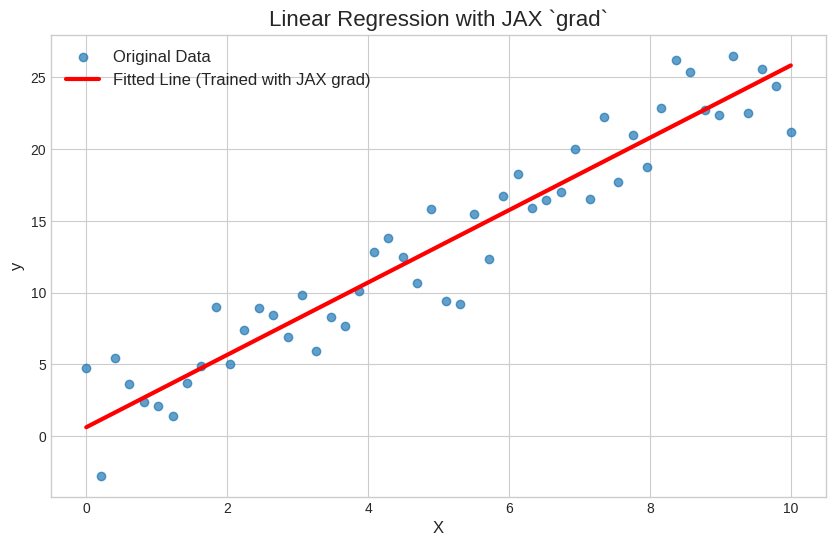

In [31]:
# @title 🚀 Gradient Descent with `jax.grad` (Manual Calculus vs. Automatic Differentiation)
# @markdown ---
# @markdown ### **The Goal: Train a Machine Learning Model**
# @markdown The most common task in machine learning is to minimize a **loss function** by adjusting model **parameters**. The most powerful tool for this is **gradient descent**, which requires calculating the derivative (or gradient) of the loss with respect to each parameter.
# @markdown
# @markdown This cell demonstrates the incredible value of `jax.grad` by comparing the old, manual way of getting gradients with the new, automatic way.

# @markdown ---
# @markdown ### **1. The "Before": The Manual, Error-Prone Approach**
# @markdown Without an automatic differentiation tool like JAX, you have to:
# @markdown 1.  **Do the calculus by hand:** Manually derive the partial derivatives of your loss function.
# @markdown 2.  **Code the math:** Carefully translate your derived formulas into a new Python function.
# @markdown
# @markdown This is slow, difficult to scale, and a major source of bugs.
# @markdown
# @markdown **Our Loss Function (Mean Squared Error):**
# @markdown $$ L(m, b) = \frac{1}{N} \sum_{i=1}^{N} ((m x_i + b) - y_i)^2 $$
# @markdown
# @markdown **Our Manually Derived Partial Derivatives:**
# @markdown $$ \frac{\partial L}{\partial m} = \frac{1}{N} \sum_{i=1}^{N} 2 \cdot ((m x_i + b) - y_i) \cdot x_i $$
# @markdown $$ \frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} 2 \cdot ((m x_i + b) - y_i) $$

# --- Imports and Data Setup ---
import jax
import jax.numpy as jnp
from jax import grad, jit
import numpy as np
import matplotlib.pyplot as plt

# Generate some sample data for our linear regression task
X_np = np.linspace(0, 10, 50)
y_np = 2.5 * X_np + 0.8 + np.random.randn(50) * 2  # y = 2.5x + 0.8 + noise
X_jnp, y_jnp = jnp.array(X_np), jnp.array(y_np)

# Initial guess for our model parameters
initial_params = {'m': 0.0, 'b': 0.0}

# --- The "BEFORE" Gradient Function (Hand-Coded Calculus) ---
def gradient_fn_manual(params, x, y):
  """
  Calculates gradients by hand-coding the derived formulas.
  This is the tedious work JAX automates.
  """
  m, b = params['m'], params['b']
  y_pred = m * x + b
  errors = y_pred - y

  # Manually coded partial derivative for 'm'
  grad_m = jnp.mean(2 * errors * x)

  # Manually coded partial derivative for 'b'
  grad_b = jnp.mean(2 * errors)

  return {'m': grad_m, 'b': grad_b}

# @markdown ---
# @markdown ### **2. The "After": The JAX `grad` Approach**
# @markdown With JAX, you only need to write the original loss function (the "forward pass"). `jax.grad` automatically creates the function that computes the gradient. It's fast, accurate, and always in sync with your loss function.

# --- The "AFTER" Gradient Function (JAX Autodiff) ---
def model(params, x):
  """A simple linear model: y = mx + b"""
  return params['m'] * x + params['b']

def loss_fn(params, x, y):
  """The Mean Squared Error loss function."""
  predictions = model(params, x)
  return jnp.mean((predictions - y)**2)

# The magic line: JAX creates the gradient function for us.
# We tell it to differentiate `loss_fn` with respect to its first argument (`params`).
gradient_fn_jax = grad(loss_fn, argnums=0)

# @markdown ---
# @markdown ### **3. Demonstrating the Value: A Direct Comparison**
# @markdown Let's run both our manual function and the JAX-generated function to prove they produce the exact same result.

# Calculate gradients both ways with the same initial parameters
manual_grads = gradient_fn_manual(initial_params, X_jnp, y_jnp)
jax_grads = gradient_fn_jax(initial_params, X_jnp, y_jnp)

print("--- Gradient Comparison ---")
print(f"Manual gradient for 'm': {manual_grads['m']:.4f}")
print(f"JAX    gradient for 'm': {jax_grads['m']:.4f}")
print(f"Manual gradient for 'b': {manual_grads['b']:.4f}")
print(f"JAX    gradient for 'b': {jax_grads['b']:.4f}\n")

# Programmatically check if they are numerically very close
are_they_close = all(jnp.allclose(manual_grads[p], jax_grads[p]) for p in initial_params)
print(f"Are the manual and JAX gradients the same? {'✅ They match perfectly!' if are_they_close else '❌ They differ!'}")

print("\nJAX saved us from doing manual calculus and coding the result, yet produced the exact same correct gradient.")
print("If we were to build a neural network, the manual method would be nearly impossible, but the JAX `grad` call would remain a single line.")

# @markdown ---
# @markdown ### **4. The Payoff: Training the Model with Effortless Gradients**
# @markdown Now, we can use our effortless JAX gradient function to train the model using gradient descent. We'll also use `jax.jit` to just-in-time compile the update step for a massive speed boost.

# JIT-compile the update step for performance
@jit
def update_step(params, x, y, learning_rate):
  """Performs one step of gradient descent."""
  gradients = gradient_fn_jax(params, x, y) # Using the effortless JAX version
  # Update each parameter by subtracting the gradient scaled by the learning rate
  return {p: params[p] - learning_rate * gradients[p] for p in params}

# --- Training Loop ---
params = {'m': 0.0, 'b': 0.0}
learning_rate = 0.001
epochs = 1000

print("\nStarting model training using JAX gradients...")
for epoch in range(epochs):
  params = update_step(params, X_jnp, y_jnp, learning_rate)
  if epoch % 200 == 0:
    current_loss = loss_fn(params, X_jnp, y_jnp)
    print(f"Epoch {epoch:4d}, Loss: {current_loss:.2f}")

print(f"\nTraining complete! Final parameters: m = {params['m']:.2f}, b = {params['b']:.2f}")
print("The true parameters were m=2.5 and b=0.8.")

# --- Visualize the result ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_np, y_np, label='Original Data', alpha=0.7)
ax.plot(X_np, model(params, X_jnp), color='red', linewidth=3, label='Fitted Line (Trained with JAX grad)')
ax.set_title('Linear Regression with JAX `grad`', fontsize=16)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=12)
plt.show()

In [32]:
# @title 4. `grad` - Automatic Differentiation

# @markdown **grad (Automatic Differentiation): Easily compute gradients.**

# @markdown JAX can automatically differentiate native Python and NumPy functions. This is incredibly powerful for machine learning, as it removes the need for manual gradient calculations.

# @markdown **Automatic Differentiation (grad)**: JAX's ability to automatically compute derivatives (gradients, Hessians, Jacobians) of arbitrary Python functions is fundamental for deep learning and scientific computing. It's powerful and simplifies complex optimization problems.

# Define a simple scalar function
def f(x):
    return x**2 + 2*x + 1

# Compute the gradient of f(x)
# The derivative of x**2 + 2*x + 1 is 2*x + 2
grad_f = grad(f)

# Evaluate the function and its gradient at a point
x_val = 3.0
print(f"Function value f({x_val}): {f(x_val)}")
print(f"Gradient of f at x={x_val}: {grad_f(x_val)}") # Expected: 2*3 + 2 = 8

# Higher-order derivatives (gradient of the gradient)
# The second derivative of f(x) is 2
grad_grad_f = grad(grad_f)
print(f"Second derivative of f at x={x_val}: {grad_grad_f(x_val)}") # Expected: 2

# Example with a simple neural network loss function
def predict(params, inputs):
    W, b = params
    outputs = jnp.dot(inputs, W) + b
    return jnp.tanh(outputs)

def loss(params, batch):
    inputs, targets = batch
    preds = predict(params, inputs)
    return jnp.mean((preds - targets)**2) # Mean squared error

# Initialize random parameters for the model
key_model = jax.random.PRNGKey(3)
W_init = jax.random.normal(key_model, (5, 10))
b_init = jnp.zeros(10)
initial_params = (W_init, b_init)

# Create some dummy data
key_data = jax.random.PRNGKey(4)
dummy_inputs = jax.random.normal(key_data, (32, 5)) # 32 examples, 5 features
dummy_targets = jax.random.normal(key_data, (32, 10)) # 32 examples, 10 output classes
dummy_batch = (dummy_inputs, dummy_targets)

# Compute the loss
current_loss = loss(initial_params, dummy_batch)
print(f"\nInitial loss: {current_loss:.4f}")

# Compute the gradient of the loss with respect to the parameters
# JAX returns a tuple of gradients corresponding to the input 'params' tuple
gradients = grad(loss)(initial_params, dummy_batch)

print("\nGradients of the loss with respect to model parameters (W, b):")
print(f"Gradient for W (shape): {gradients[0].shape}")
print(f"Gradient for b (shape): {gradients[1].shape}")

# This enables easy implementation of optimization algorithms like Gradient Descent.

Function value f(3.0): 16.0
Gradient of f at x=3.0: 8.0
Second derivative of f at x=3.0: 2.0

Initial loss: 1.5437

Gradients of the loss with respect to model parameters (W, b):
Gradient for W (shape): (5, 10)
Gradient for b (shape): (10,)


JAX is running on: TPU
Number of available devices: 8

Problem Setup:
Shape of our matrix: (100, 100)
Shape of our batch of vectors: (5000, 100)

Timing the naive for loop...
For loop execution time: 0.2726 seconds

Timing the jax.vmap function (JIT-compiled)...
vmap execution time: 0.0004 seconds


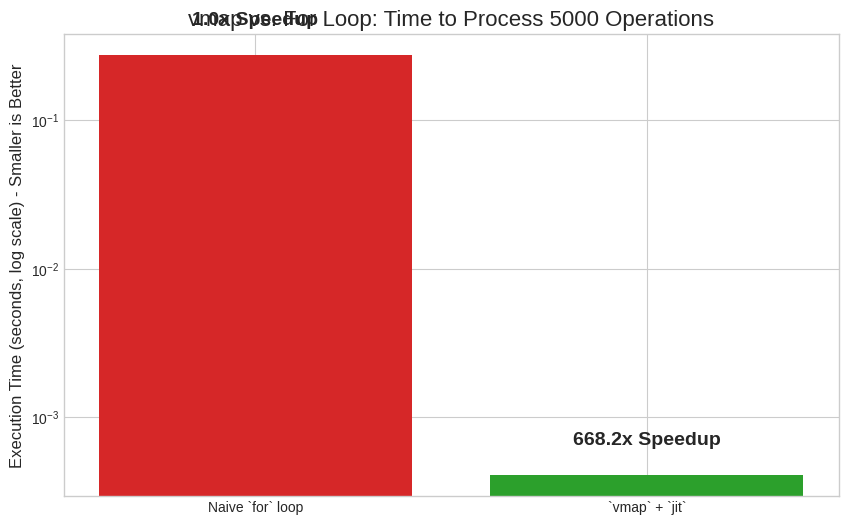


| Method              | Execution Time (s) | Speedup vs. Loop | What it Does |
| :------------------ | :----------------- | :--------------- | :----------- |
| **Naive `for` loop**| `0.2726`          | `1.0x`           | Processes data serially, one item at a time. Very slow. |
| **`vmap` + `jit`**  | `0.0004`          | `**668.2x**`     | **Vectorizes** the operation to run efficiently in parallel on a single device. |

**Conclusion:** `vmap` is the key to performance in JAX. It transforms slow Python loops into highly efficient, vectorized computations with a single line of code.


In [33]:
# @title 🚀 The Power of `vmap`: From Slow Loops to Automatic Vectorization
# @markdown ---
# @markdown ### **The Goal: Process a Batch of Data on a Single Device**
# @markdown A core task in machine learning is applying the same operation to a large batch of data. The naive approach is a Python `for` loop, which is incredibly slow.
# @markdown
# @markdown This demo shows how **`jax.vmap`** (vector map) solves this by transforming a function that works on a single data point into one that processes an entire batch in a highly optimized, parallel way on a single accelerator (like one GPU or TPU core).

# --- Imports and Data Setup ---
import jax
import jax.numpy as jnp
from jax import vmap, jit
import numpy as np
import matplotlib.pyplot as plt
import time

# Use a problem size that makes the performance difference obvious
N = 5000  # Batch size
dim = 100   # Dimension of vectors/matrix

# Create a random matrix and a batch of vectors
key = jax.random.PRNGKey(0)
matrix = jax.random.normal(key, (dim, dim))
batched_vectors = jax.random.normal(key, (N, dim))

print(f"JAX is running on: {jax.default_backend().upper()}")
print(f"Number of available devices: {jax.local_device_count()}")
print(f"\nProblem Setup:")
print(f"Shape of our matrix: {matrix.shape}")
print(f"Shape of our batch of vectors: {batched_vectors.shape}")

# @markdown ---
# @markdown ### **1. The "Before": A Slow Python `for` Loop**
# @markdown This is the standard, intuitive way to solve the problem. We write a function for one operation and loop over our batch. While easy to write, this is the slowest method as it processes data item-by-item.

def matrix_vector_product(matrix, vector):
  """Applies a matrix to a SINGLE vector."""
  return jnp.dot(matrix, vector)

# Time the for loop execution
print("\nTiming the naive for loop...")
start_time = time.time()
# The list comprehension creates a Python loop
loop_results = [matrix_vector_product(matrix, vec) for vec in batched_vectors]
# Ensure the computation is finished before stopping the timer
for res in loop_results:
    res.block_until_ready()
loop_time = time.time() - start_time
print(f"For loop execution time: {loop_time:.4f} seconds")

# @markdown ---
# @markdown ### **2. The `vmap` Way: Automatic Vectorization**
# @markdown With `vmap`, we tell JAX to map our function over the first axis of `batched_vectors`. JAX automatically transforms this into a highly optimized, single operation without any loops.
# @markdown
# @markdown **Notice we are still using the exact same function that works on a *single* example!**

# Create a vectorized version of our function using vmap.
# in_axes=(None, 0) means:
# - Don't map over the first argument (matrix).
# - Map over the first axis (axis 0) of the second argument (batched_vectors).
vmapped_fn = vmap(matrix_vector_product, in_axes=(None, 0))

# Time the vmapped function. We'll also `jit`-compile it for maximum speed.
print("\nTiming the jax.vmap function (JIT-compiled)...")
jitted_vmapped_fn = jit(vmapped_fn)

# Run once to allow JAX to JIT-compile the function.
_ = jitted_vmapped_fn(matrix, batched_vectors).block_until_ready()

# Run again to get an accurate timing measurement.
start_time = time.time()
vmap_results = jitted_vmapped_fn(matrix, batched_vectors).block_until_ready()
vmap_time = time.time() - start_time
print(f"vmap execution time: {vmap_time:.4f} seconds")

# @markdown ---
# @markdown ### **3. 💡 `vmap` Speedup**
# @markdown The plot below shows the execution time on a logarithmic scale. **Smaller is better.**

# --- Create the bar chart for visualization ---
methods = ['Naive `for` loop', '`vmap` + `jit`']
times = [loop_time, vmap_time]
speedups = [loop_time / t for t in times]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(methods, times, color=['#d62728', '#2ca02c'])
ax.set_yscale('log')
ax.set_ylabel('Execution Time (seconds, log scale) - Smaller is Better', fontsize=12)
ax.set_title(f'vmap vs. For Loop: Time to Process {N} Operations', fontsize=16)

# Add speedup text on top of the bars
for bar, speedup in zip(bars, speedups):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval * 1.5,
            f'{speedup:.1f}x Speedup', ha='center', va='bottom',
            fontsize=14, fontweight='bold')

plt.show()

from IPython.display import display, Markdown
summary_md = f"""
| Method              | Execution Time (s) | Speedup vs. Loop | What it Does |
| :------------------ | :----------------- | :--------------- | :----------- |
| **Naive `for` loop**| `{loop_time:.4f}`          | `1.0x`           | Processes data serially, one item at a time. Very slow. |
| **`vmap` + `jit`**  | `{vmap_time:.4f}`          | `**{speedups[1]:.1f}x**`     | **Vectorizes** the operation to run efficiently in parallel on a single device. |

**Conclusion:** `vmap` is the key to performance in JAX. It transforms slow Python loops into highly efficient, vectorized computations with a single line of code.
"""
display(Markdown(summary_md))

Original batch data:
[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]

Result from Python loop:
[[ 6.  8. 10. 12.]
 [30. 32. 34. 36.]
 [54. 56. 58. 60.]]
Result from vmap:
[[ 6.  8. 10. 12.]
 [30. 32. 34. 36.]
 [54. 56. 58. 60.]]

Vectors1:
[[ 0.  1.  2.  3.  4.]
 [ 5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14.]]
Vectors2:
[[15. 16. 17. 18. 19.]
 [20. 21. 22. 23. 24.]
 [25. 26. 27. 28. 29.]]
Result of batched dot product:
[ 180.  780. 1630.]

Speed comparison (conceptual, for demonstration):
Average time (Python loop): 0.297704 seconds
Vmap first run (with compilation): 0.001944 seconds
Average time (vmap subsequent runs): 0.001307 seconds
Jitted Vmap first run (with compilation): 0.047449 seconds
Average time (Jitted Vmap subsequent runs): 0.000228 seconds
Speedup vmap vs Python loop: 227.84x
Speedup jitted vmap vs raw vmap: 5.72x (showing benefits of JIT after warm-up)


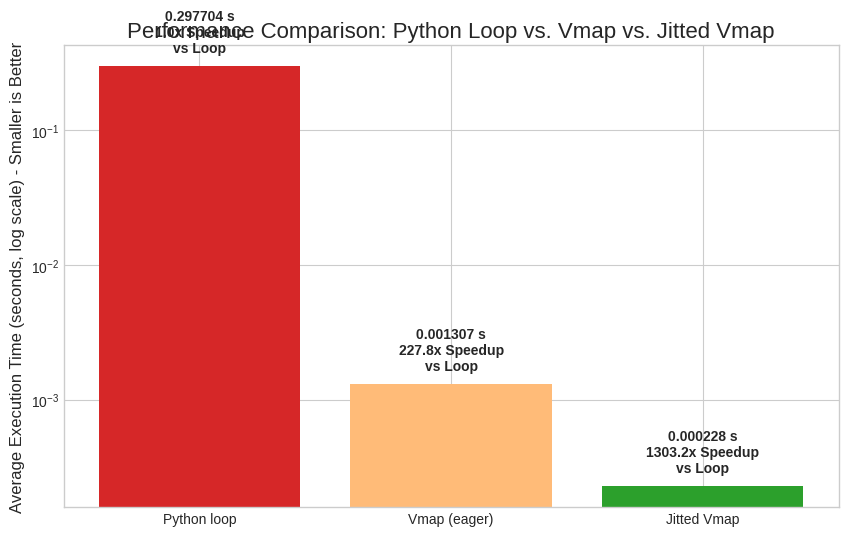

In [34]:
# @title 5. `vmap` - Automatic Vectorization (Batching)

# @markdown **vmap (Automatic Vectorization/Batching): Efficiently run a function over batch dimensions.**

# @markdown `vmap` (vectorizing map) automatically transforms a function that operates on a single data example into one that operates on a batch of examples. This avoids explicit loops and often leads to more efficient compiled code.

# @markdown **vmap (Automatic Vectorization)**: Efficiently maps a single-example function over batch dimensions without explicit loops, leading to cleaner and often faster code.


# Define a function for a single example
def single_example_process(x):
    return x * 2 + jnp.sum(x)

# Create a batch of data
batch_data = jnp.arange(12, dtype=jnp.float32).reshape(3, 4)
print(f"Original batch data:\n{batch_data}")

# Apply `single_example_process` using a Python loop (less efficient)
result_loop = jnp.stack([single_example_process(row) for row in batch_data])
print(f"\nResult from Python loop:\n{result_loop}")

# Apply `single_example_process` using `vmap`
# By default, vmap maps over the first axis of inputs and stacks over the first axis of outputs
batched_process = vmap(single_example_process)
result_vmap = batched_process(batch_data)
print(f"Result from vmap:\n{result_vmap}")

# `vmap` also works on arbitrary internal axes using `in_axes` and `out_axes`
# Example: Batching a dot product
def dot_product_vmap_example(x, y):
    return jnp.dot(x, y)

# Create two batches of vectors (each batch has 3 vectors of size 5)
vectors1 = jnp.arange(15, dtype=jnp.float32).reshape(3, 5)
vectors2 = jnp.arange(15, 30, dtype=jnp.float32).reshape(3, 5)
print(f"\nVectors1:\n{vectors1}\nVectors2:\n{vectors2}")

# We want to compute dot product for each pair of vectors (vectors1[i] . vectors2[i])
# Default in_axes=(0, 0) means map over the 0th axis of both inputs
batched_dot_product = vmap(dot_product_vmap_example)
result_batched_dot_product = batched_dot_product(vectors1, vectors2)
print(f"Result of batched dot product:\n{result_batched_dot_product}")
# The result is a 1D array of 3 dot products.

# Combining `jit` and `vmap` for performance
# Jitting a vmapped function can yield impressive speedups
jitted_batched_process = jit(batched_process)

# Time comparison (conceptual, actual timing depends on complexity and hardware)
# `timeit` can be tricky with JAX if not blocking until ready
# Here, we'll demonstrate the principle of speedup.
print("\nSpeed comparison (conceptual, for demonstration):")

# Larger batch for timing
large_batch_data = jax.random.normal(jax.random.PRNGKey(5), (1000, 100), dtype=jnp.float32)

# Timing Python loop
loop_time = timeit.timeit(lambda: jnp.stack([single_example_process(row) for row in large_batch_data]).block_until_ready(), number=5) / 5
print(f"Average time (Python loop): {loop_time:.6f} seconds")

# Timing vmap (first run includes compilation)
start_time = timeit.default_timer()
_ = batched_process(large_batch_data).block_until_ready()
vmap_first_time = timeit.default_timer() - start_time
print(f"Vmap first run (with compilation): {vmap_first_time:.6f} seconds")

# Timing subsequent vmap runs
vmap_time = timeit.timeit(lambda: batched_process(large_batch_data).block_until_ready(), number=5) / 5
print(f"Average time (vmap subsequent runs): {vmap_time:.6f} seconds")

# Timing jitted vmap (first run includes compilation)
start_time = timeit.default_timer()
_ = jitted_batched_process(large_batch_data).block_until_ready()
jit_vmap_first_time = timeit.default_timer() - start_time
print(f"Jitted Vmap first run (with compilation): {jit_vmap_first_time:.6f} seconds")

# Timing subsequent jitted vmap runs
jit_vmap_time = timeit.timeit(lambda: jitted_batched_process(large_batch_data).block_until_ready(), number=5) / 5
print(f"Average time (Jitted Vmap subsequent runs): {jit_vmap_time:.6f} seconds")

if vmap_time > 0:
    print(f"Speedup vmap vs Python loop: {loop_time/vmap_time:.2f}x")
if jit_vmap_time > 0:
    print(f"Speedup jitted vmap vs raw vmap: {vmap_time/jit_vmap_time:.2f}x (showing benefits of JIT after warm-up)")

# --- Add Visualization ---
methods = ['Python loop', 'Vmap (eager)', 'Jitted Vmap']
times = [loop_time, vmap_time, jit_vmap_time]
speedups_vs_loop = [loop_time / t if t > 0 else 0 for t in times] # Calculate speedup vs loop

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, times, color=['#d62728', '#ffbb78', '#2ca02c']) # Red, Light Orange, Green
plt.yscale('log')
plt.ylabel('Average Execution Time (seconds, log scale) - Smaller is Better', fontsize=12)
plt.title('Performance Comparison: Python Loop vs. Vmap vs. Jitted Vmap', fontsize=16)

# Add time and speedup text on top of the bars
for bar, speedup in zip(bars, speedups_vs_loop):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval * 1.2,
             f'{yval:.6f} s\n{speedup:.1f}x Speedup\nvs Loop', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.show()

JAX is running on: TPU with 8 devices.

--- Running Experiment: Small Problem ---
Batch size (N) = 4000, Dimension = 512, MatMuls per item = 10
  `vmap` time on 1 device: 0.00236 seconds
  `pmap` time on 8 devices: 0.00928 seconds

--- Running Experiment: Large Problem ---
Batch size (N) = 64000, Dimension = 1024, MatMuls per item = 50
  `vmap` time on 1 device: 0.41794 seconds
  `pmap` time on 8 devices: 0.29822 seconds


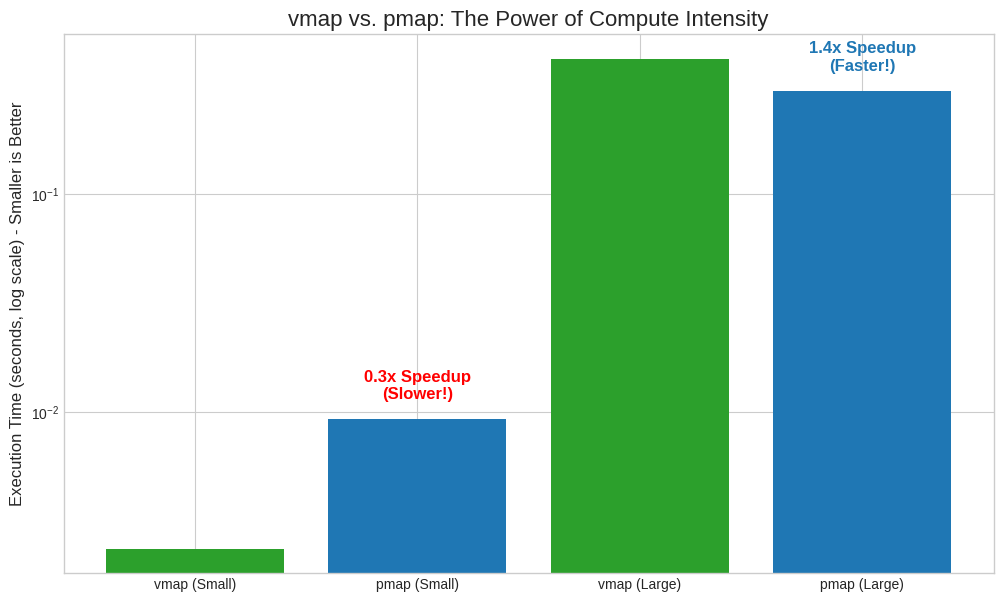


**Conclusion:** This demonstrates the core principle of parallelization: **`pmap` is effective when the work done in parallel is significantly greater than the overhead of coordinating it.**

-   For tasks with low arithmetic intensity, the cost of splitting and gathering data makes `pmap` slower.
-   For tasks with **high arithmetic intensity** (many calculations per byte), `pmap` provides dramatic speedups by leveraging all available hardware, making it essential for scaling large-scale computations like training deep neural networks.


In [35]:
# @title 🚀 Scaling Up with `pmap`: The Power of Compute Intensity
# @markdown ---
# @markdown ### **The Goal: Understand When to Use `pmap`**
# @markdown Our previous experiment showed that for fast operations, `pmap`'s overhead can make it slower than `vmap`. This is because the task was **memory-bound** (limited by data transfer speed) rather than **compute-bound** (limited by raw calculation speed).
# @markdown
# @markdown To see `pmap`'s true power, we need a task with **high arithmetic intensity**—lots of calculations per byte of data. A chain of matrix multiplications is a perfect example, simulating a block of a neural network.

# --- Imports and Setup ---
import jax
import jax.numpy as jnp
from jax import vmap, pmap, jit
import numpy as np
import matplotlib.pyplot as plt
import time
from functools import partial

num_devices = jax.local_device_count()
print(f"JAX is running on: {jax.default_backend().upper()} with {num_devices} devices.")

# @markdown ---
# @markdown ### **The "Compute-Intensive" Function**
# @markdown Instead of one matrix multiplication, we'll do several in a sequence. We pass `num_multiplies` as a **static argument** because it controls the structure of the compiled code (how many times the loop unrolls).

@partial(jit, static_argnums=(2,)) # JIT-compile this core function
def heavy_computation(matrices, vector, num_multiplies):
  """Applies a sequence of matrix multiplications to a single vector."""
  # We use a JAX fori_loop for performance instead of a Python for loop.
  def body_fun(i, val):
    return jnp.dot(matrices[i], val)

  return jax.lax.fori_loop(0, num_multiplies, body_fun, vector)

# --- This function will run our timing comparison ---
def run_comparison(N, dim, num_mats, title):
    print(f"\n--- Running Experiment: {title} ---")
    print(f"Batch size (N) = {N}, Dimension = {dim}, MatMuls per item = {num_mats}")

    key = jax.random.PRNGKey(0)
    # Create a "stack" of matrices for our heavy computation
    matrices = jax.random.normal(key, (num_mats, dim, dim))
    batched_vectors = jax.random.normal(key, (N, dim))

    # --- VMAP TIMING (Single Device) ---
    # `vmap` the heavy_computation function, then jit the *result*.
    # We tell jit that the 3rd argument (index 2) is static.
    vmapped_fn = vmap(heavy_computation, in_axes=(None, 0, None))
    jitted_vmapped_fn = jit(vmapped_fn, static_argnums=(2,))

    # Compile
    _ = jitted_vmapped_fn(matrices, batched_vectors, num_mats).block_until_ready()

    # Time
    start_time = time.time()
    _ = jitted_vmapped_fn(matrices, batched_vectors, num_mats).block_until_ready()
    vmap_time = time.time() - start_time
    print(f"  `vmap` time on 1 device: {vmap_time:.5f} seconds")

    # --- PMAP TIMING (All Devices) ---
    if N % num_devices != 0:
        print(f"  Cannot run pmap: Batch size {N} is not divisible by {num_devices} devices.")
        return vmap_time, -1

    sharded_vectors = batched_vectors.reshape(num_devices, -1, dim)

    # The correct pattern: pmap over the vmapped function.
    # We tell pmap that its 3rd argument (index 2) is static.
    pmapped_fn = pmap(
        vmap(heavy_computation, in_axes=(None, 0, None)), # Function to parallelize
        in_axes=(None, 0, None),                         # How to map arguments
        static_broadcasted_argnums=(2,)                  # Which argument is static
    )

    # Compile
    _ = pmapped_fn(matrices, sharded_vectors, num_mats).block_until_ready()

    # Time
    start_time = time.time()
    _ = pmapped_fn(matrices, sharded_vectors, num_mats).block_until_ready()
    pmap_time = time.time() - start_time
    print(f"  `pmap` time on {num_devices} devices: {pmap_time:.5f} seconds")

    return vmap_time, pmap_time

# @markdown ---
# @markdown ### **Experiment 1: Small Problem (Low Compute Intensity)**
# @markdown We'll start with a small batch and only a few multiplications. As expected, `pmap`'s overhead should make it slower.

small_vmap_time, small_pmap_time = run_comparison(N=4000, dim=512, num_mats=10, title="Small Problem")

# @markdown ---
# @markdown ### **Experiment 2: Large Problem (High Compute Intensity)**
# @markdown Now, we drastically increase the batch size, the matrix size, and the number of multiplications. This is a truly "heavy" task. Watch `pmap` demonstrate its scaling power.

large_vmap_time, large_pmap_time = run_comparison(N=64000, dim=1024, num_mats=50, title="Large Problem")

# @markdown ---
# @markdown ### **💡 Compute Intensity Unlocks `pmap`'s Power**
# @markdown The plot clearly shows that when the workload is heavy enough, `pmap` provides a significant performance boost. **`vmap` is green** and **`pmap` is blue**.

# --- Create the bar chart for visualization ---
methods = [
    'vmap (Small)', 'pmap (Small)',
    'vmap (Large)', 'pmap (Large)'
]
times = [small_vmap_time, small_pmap_time, large_vmap_time, large_pmap_time]

# Use consistent colors: one for vmap, one for pmap
vmap_color = '#2ca02c'  # Green
pmap_color = '#1f77b4'  # Blue
colors = [vmap_color, pmap_color, vmap_color, pmap_color]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(methods, times, color=colors)
ax.set_yscale('log')
ax.set_ylabel('Execution Time (seconds, log scale) - Smaller is Better', fontsize=12)
ax.set_title('vmap vs. pmap: The Power of Compute Intensity', fontsize=16)

# Add speedup annotations
if small_pmap_time > 0:
    small_speedup = small_vmap_time / small_pmap_time
    ax.text(bars[1].get_x() + bars[1].get_width()/2.0, times[1] * 1.2,
            f'{small_speedup:.1f}x Speedup\n(Slower!)', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='red') # Red text for emphasis

if large_pmap_time > 0:
    large_speedup = large_vmap_time / large_pmap_time
    ax.text(bars[3].get_x() + bars[3].get_width()/2.0, times[3] * 1.2,
            f'{large_speedup:.1f}x Speedup\n(Faster!)', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=pmap_color) # Blue text to match bar

plt.show()

from IPython.display import display, Markdown
summary_md = f"""
**Conclusion:** This demonstrates the core principle of parallelization: **`pmap` is effective when the work done in parallel is significantly greater than the overhead of coordinating it.**

-   For tasks with low arithmetic intensity, the cost of splitting and gathering data makes `pmap` slower.
-   For tasks with **high arithmetic intensity** (many calculations per byte), `pmap` provides dramatic speedups by leveraging all available hardware, making it essential for scaling large-scale computations like training deep neural networks.
"""
display(Markdown(summary_md))

Number of available devices: 8

Performing parallel matrix multiplication on 8 devices.
Each device handles a 1000x1000 matrix multiply.

PMAP first call (including compilation): 75.934591 seconds
Average PMAP subsequent call (5 runs): 0.004031 seconds

Local values on devices (replica IDs): [0. 1. 2. 3. 4. 5. 6. 7.]
Summed value (replicated on each device): [[28.]
 [28.]
 [28.]
 [28.]
 [28.]
 [28.]
 [28.]
 [28.]]
Expected sum: 28

Plotting pmap performance...


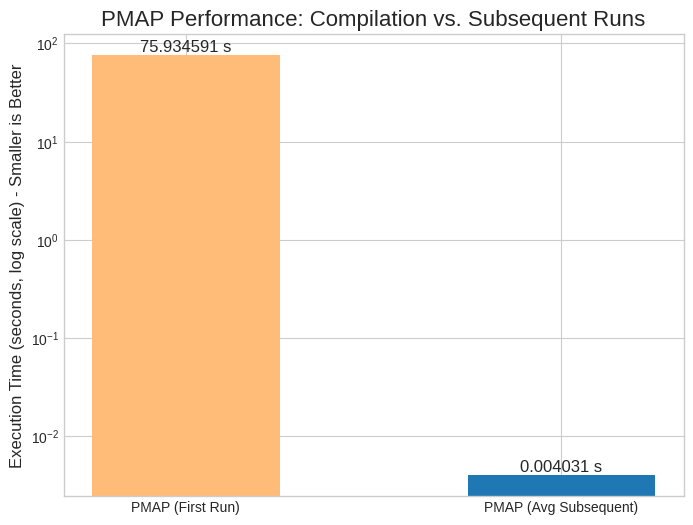

In [36]:
# @title 6. `pmap` - Automatic Parallelization across Devices

# @markdown **pmap (Automatic Parallelization): Scale computations across multiple devices (if available).**

# @markdown `pmap` (parallel map) maps a function over multiple devices (e.g., multiple GPUs or TPU cores). It is used for data parallelism, where each device processes a slice of the input data.

# @markdown **pmap (Automatic Parallelization)**: Enables easy scaling of computations across multiple accelerator devices by automatically splitting data and managing communication, abstracting away complex distributed programming details.

num_devices = jax.device_count()
print(f"Number of available devices: {num_devices}")

if num_devices > 1:
    # Define a function to run in parallel on each device
    # `axis_name` allows for collective communication operations
    @functools.partial(pmap, axis_name='devices')
    def parallel_matrix_multiply(key, data_shard):
        # Use a unique key for each replica
        local_key = jax.random.fold_in(key, jax.lax.axis_index('devices'))
        mat1 = jax.random.normal(local_key, data_shard.shape)
        mat2 = jax.random.normal(local_key, data_shard.shape)
        return jnp.dot(mat1, mat2)

    # Create dummy data that can be sharded across devices
    # Total input size for all devices
    total_matrix_size = 8000 # Adjust based on memory
    single_shard_size = total_matrix_size // num_devices

    # Generate input data for each device.
    # The leading dimension of the input array must match `num_devices`.
    key_pmap = jax.random.PRNGKey(6)
    sharded_data = jax.random.normal(key_pmap, (num_devices, single_shard_size, single_shard_size), dtype=jnp.float32)

    print(f"\nPerforming parallel matrix multiplication on {num_devices} devices.")
    print(f"Each device handles a {single_shard_size}x{single_shard_size} matrix multiply.")

    # --- First call with pmap (includes compilation and data transfer) ---
    start_time = timeit.default_timer()
    # The result will be a ShardedDeviceArray, with outputs from each device
    # Pass sharded keys for the initial compilation run as well
    initial_keys_sharded = jax.random.split(key_pmap, num_devices)
    _ = parallel_matrix_multiply(initial_keys_sharded, sharded_data).block_until_ready()
    pmap_first_call_time = timeit.default_timer() - start_time
    print(f"\nPMAP first call (including compilation): {pmap_first_call_time:.6f} seconds")

    # --- Subsequent calls with pmap (reusing compiled code) ---
    num_runs_pmap = 5
    total_pmap_subsequent_time = 0
    # Generate enough keys for each run and each device *outside* the timing loop
    # We need num_runs_pmap sets of keys, where each set has a key for each device
    keys_for_subsequent_runs_sets = jax.random.split(jax.random.PRNGKey(7), num_runs_pmap)
    # For each run, we need to split the run-specific key into num_devices keys
    all_run_keys_sharded = jnp.stack([jax.random.split(run_key, num_devices) for run_key in keys_for_subsequent_runs_sets])


    for i in range(num_runs_pmap):
        # Pass the set of keys for the current run to the pmapped function
        # This set of keys already has the shape (num_devices, 2) which pmap expects
        run_keys_sharded = all_run_keys_sharded[i]

        start_time = timeit.default_timer()
        _ = parallel_matrix_multiply(run_keys_sharded, sharded_data).block_until_ready()
        total_pmap_subsequent_time += (timeit.default_timer() - start_time)

    avg_pmap_subsequent_time = total_pmap_subsequent_time / num_runs_pmap
    print(f"Average PMAP subsequent call ({num_runs_pmap} runs): {avg_pmap_subsequent_time:.6f} seconds")

    # --- Collective Communication example: `psum` ---
    # `psum` sums values across all devices for a given axis_name.
    # The result is replicated on all devices.
    @functools.partial(pmap, axis_name='devices')
    def collective_sum(x):
        return jax.lax.psum(x, axis_name='devices')

    # Each device has a local value (e.g., its replica ID)
    # Use axis_index here too for consistency and correctness
    replica_ids = jnp.arange(num_devices, dtype=jnp.float32) # This creates a single array on the host
    # We need to pass a sharded array to pmap. A common pattern is to create a constant
    # sharded array where each shard is the replica index.
    sharded_replica_ids = jnp.arange(num_devices, dtype=jnp.float32).reshape(num_devices, 1) # Reshape to (num_devices, 1)
    print(f"\nLocal values on devices (replica IDs): {sharded_replica_ids.flatten()}") # Flatten for printing

    # Perform a collective sum
    # Pass the sharded_replica_ids to the pmapped function
    summed_value = collective_sum(sharded_replica_ids)
    print(f"Summed value (replicated on each device): {summed_value}")
    print(f"Expected sum: {sum(range(num_devices))}") # Sum of 0 to num_devices-1

    # --- Add Visualization ---
    print("\nPlotting pmap performance...")
    methods = ['PMAP (First Run)', 'PMAP (Avg Subsequent)']
    times = [pmap_first_call_time, avg_pmap_subsequent_time]
    colors = ['#ffbb78', '#1f77b4'] # Light Orange, Blue

    plt.figure(figsize=(8, 6))
    bars = plt.bar(methods, times, color=colors, width=0.5)
    plt.yscale('log')
    plt.ylabel('Execution Time (seconds, log scale) - Smaller is Better', fontsize=12)
    plt.title('PMAP Performance: Compilation vs. Subsequent Runs', fontsize=16)

    # Add time text on top of the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.6f} s', ha='center', va='bottom', fontsize=12)

    plt.show()


else:
    print("Skipping pmap demonstration: Less than 2 devices available.")
    print("To run pmap, change your Colab runtime to GPU or TPU and ensure multiple cores are available.")

# Summary: JAX's combination of NumPy-like syntax with powerful function transformations for performance, automatic differentiation, and scaling makes it a highly effective tool for high-performance machine learning research.